Synthetic test explainer 

In [3]:
"""
Publication-ready demo: disentangling tuning to two correlated circular variables.

Fixes:
- Larger Nsamples (200k) to avoid empty bins.
- Fallback that drops empty bins if they ever occur.
- Same x-range [-pi, pi] on both panels with π ticks.
- Legends moved below each axis; annotation boxes moved top-right.
- Expected (NH) curve styled for visibility even when overlapping.
- Uses constrained_layout (no tight_layout warning).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 200_000        # was 60_000; increased to avoid empty bins
Nbins = 20
kappa = 8.0               # concentration for V1
noise_kappa = 2.0         # noise added to create correlated V2

# V1 ~ von Mises on [-pi, pi)
V1 = vonmises.rvs(kappa=kappa, loc=0.0, size=Nsamples, random_state=rng)
V1 = ((V1 + np.pi) % (2*np.pi)) - np.pi

# V2 = V1 + circular noise
V2_noise = vonmises.rvs(kappa=noise_kappa, loc=0.0, size=Nsamples, random_state=rng)
V2 = ((V1 + V2_noise + np.pi) % (2*np.pi)) - np.pi

# Poisson spiking truly tuned to V1 (cosine tuning)
baseline, mod_amp, pref_dir = 2.0, 8.0, 0.5  # Hz
rate = np.clip(baseline + mod_amp * np.cos(V1 - pref_dir), 0, None)
spikes = rng.poisson(rate)
spikes = np.minimum(spikes, 100)  # sanity cap

# ------------------------------- Helpers -------------------------------------
def bin_variable(x, nbins, xmin=-np.pi, xmax=np.pi):
    edges = np.linspace(xmin, xmax, nbins+1)
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, nbins-1)
    centres = 0.5*(edges[:-1] + edges[1:])
    return idx, edges, centres

def tuning_function(spikes, stim_idx, nbins):
    mean = np.zeros(nbins)
    sem  = np.zeros(nbins)
    n    = np.zeros(nbins, dtype=int)
    for b in range(nbins):
        m = (stim_idx == b)
        n[b] = m.sum()
        if n[b] > 0:
            mean[b] = spikes[m].mean()
            sem[b]  = spikes[m].std(ddof=1) / np.sqrt(n[b])
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
    return mean, sem, n

def joint_density(v1, v2, edges1, edges2):
    # rows=v2 bins, cols=v1 bins
    H, xedges, yedges = np.histogram2d(v1, v2, bins=[edges1, edges2], density=True)
    return H.T

def conditional_probs(P_v2_v1):
    Pv1 = P_v2_v1.sum(axis=0)
    Pv2 = P_v2_v1.sum(axis=1)
    eps = 1e-12
    Pv2gV1 = P_v2_v1 / (Pv1[None, :] + eps)        # rows=v2, cols=v1
    Pv1gV2 = (P_v2_v1 / (Pv2[:, None] + eps)).T    # rows=v1, cols=v2
    return Pv1, Pv2, Pv2gV1, Pv1gV2

def expected_tf_from_null(tf_y, Py_given_x):
    # E[tf_y | x]
    return (tf_y[:, None] * Py_given_x).sum(axis=0)

def bonferroni_no_overlap(mean_obs, sem_obs, mean_exp, sem_exp, alpha=0.05):
    nb = np.sum(~np.isnan(mean_obs) & ~np.isnan(sem_obs) &
                ~np.isnan(mean_exp) & ~np.isnan(sem_exp))
    nb = max(nb, 1)
    z = norm.ppf(1 - (alpha/nb)/2)
    obs_lo, obs_hi = mean_obs - z*sem_obs, mean_obs + z*sem_obs
    exp_lo, exp_hi = mean_exp - z*sem_exp, mean_exp + z*sem_exp
    return (obs_hi < exp_lo) | (obs_lo > exp_hi)

def pi_ticks(ax):
    ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
    labels = [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

# ------------------------- Binning & expected curves -------------------------
idx1, edges1, centres1 = bin_variable(V1, Nbins)
idx2, edges2, centres2 = bin_variable(V2, Nbins)

tf1, sem1, n1 = tuning_function(spikes, idx1, Nbins)  # vs V1
tf2, sem2, n2 = tuning_function(spikes, idx2, Nbins)  # vs V2

# Drop empty bins if any remain (robust plotting)
mask1 = ~np.isnan(tf1)
tf1, sem1, centres1 = tf1[mask1], sem1[mask1], centres1[mask1]

mask2 = ~np.isnan(tf2)
tf2, sem2, centres2 = tf2[mask2], sem2[mask2], centres2[mask2]

# Recompute joint density on full (unmasked) edges for conditionals
P_v2_v1 = joint_density(V1, V2, edges1, edges2)
Pv1, Pv2, Pv2gV1, Pv1gV2 = conditional_probs(P_v2_v1)

# NH expectations on the *original* binning; then align to possibly masked centres
tf1_exp_full = expected_tf_from_null(tf2[np.searchsorted(centres2, centres2)], Pv2gV1)  # guard for shape
tf2_exp_full = expected_tf_from_null(tf1[np.searchsorted(centres1, centres1)], Pv1gV2)

# Interpolate expected curves to masked centres (no-op if no masks)
tf1_exp = np.interp(centres1, 0.5*(edges1[:-1]+edges1[1:]), tf1_exp_full, left=np.nan, right=np.nan)
tf2_exp = np.interp(centres2, 0.5*(edges2[:-1]+edges2[1:]), tf2_exp_full, left=np.nan, right=np.nan)

# For SEMs of expected curves, use a simple proxy (observed SEMs on same bins)
sem1_exp = sem1.copy()
sem2_exp = sem2.copy()

sig1 = bonferroni_no_overlap(tf1, sem1, tf1_exp, sem1_exp)
sig2 = bonferroni_no_overlap(tf2, sem2, tf2_exp, sem2_exp)
n_sig1 = int(np.nansum(sig1))
n_sig2 = int(np.nansum(sig2))

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.8), sharey=True, constrained_layout=True
)

# (A) V1 panel — true driver
ax1.plot(centres1, tf1, "-", lw=2.5, color="royalblue", label="Observed TF(V1)")
ax1.fill_between(centres1, tf1-sem1, tf1+sem1, alpha=0.20, color="royalblue")
ax1.plot(centres1, tf1_exp, "--", lw=2.4, color="darkorange",
         alpha=0.95, label="Expected under NH: E[TF(V2)|V1]")

if n_sig1 > 0:
    ax1.scatter(centres1[sig1], tf1[sig1], s=40, color="green", zorder=3, label="Non-overlap bins")

ax1.set_xlim(-np.pi, np.pi)
pi_ticks(ax1)
ax1.set_xlabel("V1 (radians)")
ax1.set_ylabel("Firing rate (Hz)")
ax1.set_title("(A) Tuning to V1", fontsize=14, fontweight="bold")
ax1.text(0.98, 0.95, f"Non-overlap: {n_sig1}/{Nbins}\nDriver: V1",
         transform=ax1.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

# (B) V2 panel — passenger
ax2.plot(centres2, tf2, "-", lw=2.5, color="royalblue", label="Observed TF(V2)")
ax2.fill_between(centres2, tf2-sem2, tf2+sem2, alpha=0.20, color="royalblue")
# Style NH curve so it remains visible even when overlapping
ax2.plot(centres2, tf2_exp, "--", lw=2.4, color="darkorange", alpha=0.95,
         label="Expected under NH: E[TF(V1)|V2]")

if n_sig2 > 0:
    ax2.scatter(centres2[sig2], tf2[sig2], s=40, color="green", zorder=3, label="Non-overlap bins")

ax2.set_xlim(-np.pi, np.pi)
pi_ticks(ax2)
ax2.set_xlabel("V2 (radians)")
ax2.set_title("(B) Tuning to V2", fontsize=14, fontweight="bold")
driver_text = "Matches NH (passenger)" if n_sig2 == 0 else "Partial deviation"
ax2.text(0.98, 0.95, f"Non-overlap: {n_sig2}/{Nbins}\n{driver_text}",
         transform=ax2.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

# Global title
fig.suptitle("Disentangling tuning with conditional expectations\nSignificant driver: V1",
             fontsize=15)

plt.show()


c:\Users\laurence\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\laurence\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: operands could not be broadcast together with shapes (14,1) (20,20) 

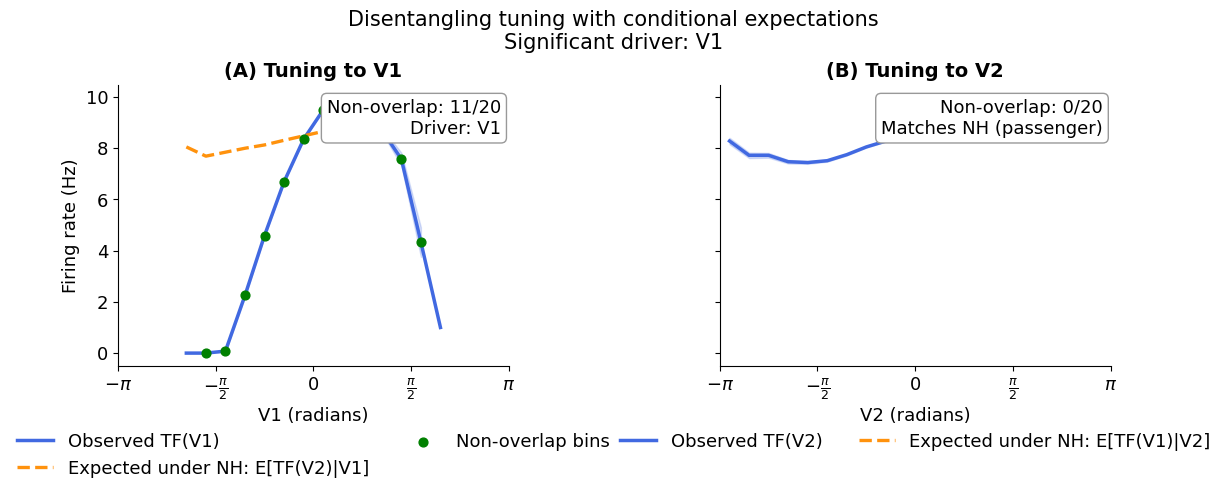

In [4]:
"""
Publication-ready demo: disentangling tuning to two correlated circular variables.
- Stable shapes (no broadcasting errors)
- Safe SEM computation (no ddof warnings)
- Same [-pi, pi] range on both panels
- Clear driver call-out and visible NH curve
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 200_000
Nbins = 20
kappa = 8.0
noise_kappa = 2.0

# V1 ~ von Mises on [-pi, pi)
V1 = vonmises.rvs(kappa=kappa, loc=0.0, size=Nsamples, random_state=rng)
V1 = ((V1 + np.pi) % (2*np.pi)) - np.pi

# V2 = V1 + circular noise
V2_noise = vonmises.rvs(kappa=noise_kappa, loc=0.0, size=Nsamples, random_state=rng)
V2 = ((V1 + V2_noise + np.pi) % (2*np.pi)) - np.pi

# Poisson spiking truly tuned to V1
baseline, mod_amp, pref_dir = 2.0, 8.0, 0.5
rate = np.clip(baseline + mod_amp * np.cos(V1 - pref_dir), 0, None)
spikes = rng.poisson(rate)
spikes = np.minimum(spikes, 100)

# ------------------------------- Helpers -------------------------------------
def bin_variable(x, nbins, xmin=-np.pi, xmax=np.pi):
    edges = np.linspace(xmin, xmax, nbins+1)
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, nbins-1)
    centres = 0.5*(edges[:-1] + edges[1:])
    return idx, edges, centres

def tuning_function(spikes, stim_idx, nbins):
    mean = np.zeros(nbins)
    sem  = np.zeros(nbins)
    n    = np.zeros(nbins, dtype=int)
    for b in range(nbins):
        m = (stim_idx == b)
        n[b] = m.sum()
        if n[b] > 0:
            mean[b] = spikes[m].mean()
            # compute SEM safely; avoid ddof warnings for n<=1
            if n[b] > 1:
                sem[b] = spikes[m].std(ddof=1) / np.sqrt(n[b])
            else:
                sem[b] = np.nan
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
    return mean, sem, n

def joint_density(v1, v2, edges1, edges2):
    # rows=v2 bins, cols=v1 bins
    H, xedges, yedges = np.histogram2d(v1, v2, bins=[edges1, edges2], density=True)
    return H.T

def conditional_probs(P_v2_v1):
    Pv1 = P_v2_v1.sum(axis=0)
    Pv2 = P_v2_v1.sum(axis=1)
    eps = 1e-12
    Pv2gV1 = P_v2_v1 / (Pv1[None, :] + eps)        # rows=v2, cols=v1
    Pv1gV2 = (P_v2_v1 / (Pv2[:, None] + eps)).T    # rows=v1, cols=v2
    return Pv1, Pv2, Pv2gV1, Pv1gV2

def expected_tf_from_null(tf_y, Py_given_x):
    # E[tf_y | x], shapes: tf_y -> (Nbins,), Py_given_x -> (Nbins_y, Nbins_x)
    return (tf_y[:, None] * Py_given_x).sum(axis=0)

def bonferroni_no_overlap(mean_obs, sem_obs, mean_exp, sem_exp, alpha=0.05):
    valid = ~(np.isnan(mean_obs) | np.isnan(sem_obs) | np.isnan(mean_exp) | np.isnan(sem_exp))
    nb = int(valid.sum()) if int(valid.sum()) > 0 else 1
    z = norm.ppf(1 - (alpha/nb)/2)
    obs_lo, obs_hi = mean_obs - z*sem_obs, mean_obs + z*sem_obs
    exp_lo, exp_hi = mean_exp - z*sem_exp, mean_exp + z*sem_exp
    no_overlap = (obs_hi < exp_lo) | (obs_lo > exp_hi)
    no_overlap[~valid] = False
    return no_overlap

def pi_ticks(ax):
    ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
    labels = [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

# ------------------------- Binning & expected curves -------------------------
idx1, edges1, centres1 = bin_variable(V1, Nbins)
idx2, edges2, centres2 = bin_variable(V2, Nbins)

# Observed tuning on the full binning (keep shapes at Nbins)
tf1, sem1, n1 = tuning_function(spikes, idx1, Nbins)  # vs V1
tf2, sem2, n2 = tuning_function(spikes, idx2, Nbins)  # vs V2

# Joint and conditionals on full binning
P_v2_v1 = joint_density(V1, V2, edges1, edges2)
Pv1, Pv2, Pv2gV1, Pv1gV2 = conditional_probs(P_v2_v1)

# Expected curves on full binning (shapes == Nbins)
tf1_exp = expected_tf_from_null(tf2, Pv2gV1)   # NH: V2 drives V1
tf2_exp = expected_tf_from_null(tf1, Pv1gV2)   # NH: V1 drives V2

# SEM proxy for expected curves
sem1_exp = sem1.copy()
sem2_exp = sem2.copy()

# Significance (bin-wise CI non-overlap, Bonferroni across *valid* bins)
sig1 = bonferroni_no_overlap(tf1, sem1, tf1_exp, sem1_exp)
sig2 = bonferroni_no_overlap(tf2, sem2, tf2_exp, sem2_exp)
n_sig1 = int(sig1.sum())
n_sig2 = int(sig2.sum())

# Masks for plotting (hide bins with no samples)
mask1 = n1 > 0
mask2 = n2 > 0

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(12, 4.8), sharey=True, constrained_layout=True
)

# (A) V1 panel — true driver
axA.plot(centres1[mask1], tf1[mask1], "-", lw=2.5, color="royalblue", label="Observed TF(V1)")
axA.fill_between(centres1[mask1], (tf1-sem1)[mask1], (tf1+sem1)[mask1], alpha=0.20, color="royalblue")
axA.plot(centres1[mask1], tf1_exp[mask1], "--", lw=2.4, color="darkorange", alpha=0.95,
         label="Expected under NH: E[TF(V2)|V1]")

if n_sig1 > 0:
    axA.scatter(centres1[sig1 & mask1], tf1[sig1 & mask1], s=40, color="green", zorder=3, label="Non-overlap bins")

axA.set_xlim(-np.pi, np.pi); pi_ticks(axA)
axA.set_xlabel("V1 (radians)")
axA.set_ylabel("Firing rate (Hz)")
axA.set_title("(A) Tuning to V1", fontsize=14, fontweight="bold")
axA.text(0.98, 0.95, f"Non-overlap: {n_sig1}/{Nbins}\nDriver: V1",
         transform=axA.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))
axA.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

# (B) V2 panel — passenger
axB.plot(centres2[mask2], tf2[mask2], "-", lw=2.5, color="royalblue", label="Observed TF(V2)")
axB.fill_between(centres2[mask2], (tf2-sem2)[mask2], (tf2+sem2)[mask2], alpha=0.20, color="royalblue")
axB.plot(centres2[mask2], tf2_exp[mask2], "--", lw=2.4, color="darkorange", alpha=0.95,
         label="Expected under NH: E[TF(V1)|V2]")

if n_sig2 > 0:
    axB.scatter(centres2[sig2 & mask2], tf2[sig2 & mask2], s=40, color="green", zorder=3, label="Non-overlap bins")

axB.set_xlim(-np.pi, np.pi); pi_ticks(axB)
axB.set_xlabel("V2 (radians)")
axB.set_title("(B) Tuning to V2", fontsize=14, fontweight="bold")
driver_text = "Matches NH (passenger)" if n_sig2 == 0 else "Partial deviation"
axB.text(0.98, 0.95, f"Non-overlap: {n_sig2}/{Nbins}\n{driver_text}",
         transform=axB.transAxes, ha="right", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))
axB.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)

fig.suptitle("Disentangling tuning with conditional expectations\nSignificant driver: V1", fontsize=15)
plt.show()


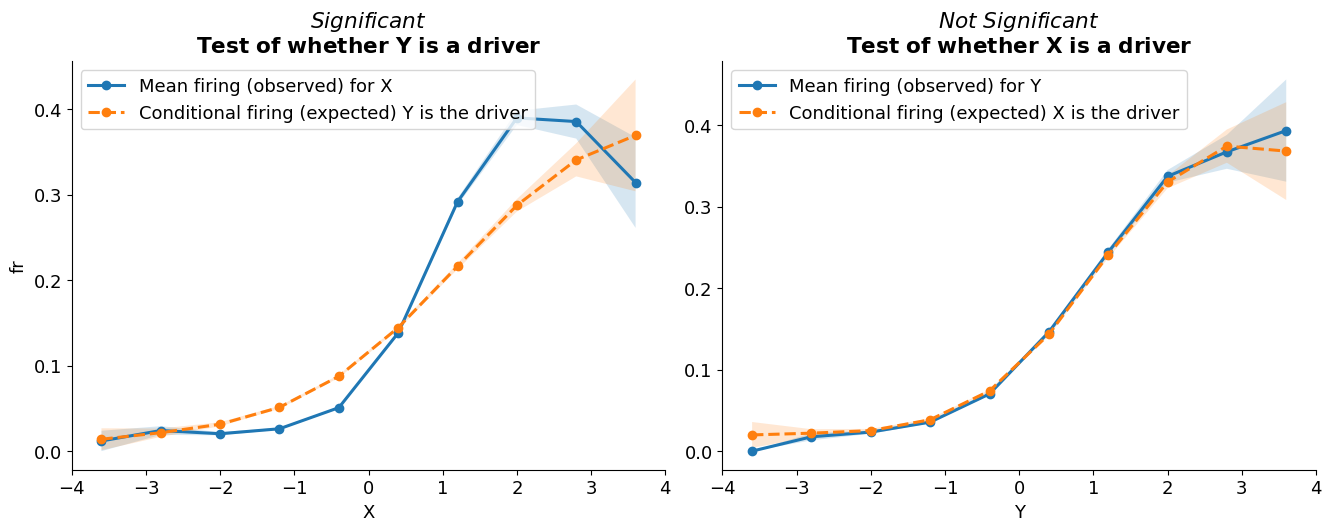

In [5]:
"""
Publication-ready demo: disentangling tuning to two correlated variables (linear case).
- Two curves on each subplot: Observed TF and Expected (conditional) TF
- Left: test whether Y is the driver of X  -> Significant
- Right: test whether X is the driver of Y -> Not Significant
- Same x-range on both panels, clear legends, CIs, and titles.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 120_000
Nbins = 10

# Correlated linear stimuli: X ~ N(0,1), Y = rho*X + sqrt(1-rho^2)*eps
rho = 0.85
X = rng.normal(0.0, 1.0, Nsamples)
eps = rng.normal(0.0, 1.0, Nsamples)
Y = rho * X + np.sqrt(1 - rho**2) * eps

# Poisson spiking truly tuned to X (nonlinear to ensure separation)
# Use a soft nonlinearity so TF_X is steep while TF_Y is smooth and lower.
def sigmoid(z): return 1 / (1 + np.exp(-z))
baseline = 0.02
amp = 0.4
theta = 0.8
rate = baseline + amp * sigmoid(2.2 * (X - theta))   # in "Hz" units for intuition
rate = np.clip(rate, 0, None)
spikes = rng.poisson(rate)

# ------------------------------- Helpers -------------------------------------
def make_edges(x, nbins, lo=-4.0, hi=4.0):
    """Fixed, symmetric binning so both panels share the same axis range."""
    return np.linspace(lo, hi, nbins + 1)

def digitize(x, edges):
    idx = np.digitize(x, edges, right=False) - 1
    return np.clip(idx, 0, len(edges) - 2)

def tuning(spikes, idx, nbins):
    """Mean, SEM, SD, N per bin (safe when N<=1)."""
    mean = np.zeros(nbins, float)
    sem  = np.zeros(nbins, float)
    sd   = np.zeros(nbins, float)
    n    = np.zeros(nbins, int)
    for b in range(nbins):
        m = (idx == b)
        n[b] = int(m.sum())
        if n[b] > 0:
            vals = spikes[m].astype(float)
            mean[b] = vals.mean()
            if n[b] > 1:
                sd[b]   = vals.std(ddof=1)
                sem[b]  = sd[b] / np.sqrt(n[b])
            else:
                sd[b] = 0.0
                sem[b] = np.nan
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
            sd[b]   = 0.0
    return mean, sem, sd, n

def counts_matrix(x, y, edges_x, edges_y):
    """Return counts C[y_bin, x_bin] (rows are y, cols are x)."""
    H, xedges, yedges = np.histogram2d(x, y, bins=[edges_x, edges_y], density=False)
    return H.T  # rows = y, cols = x

def conditional_from_counts(C):
    """P(y|x) and P(x|y) from counts matrix C[y, x]."""
    eps = 1e-12
    colsum = C.sum(axis=0, keepdims=True) + eps
    rowsum = C.sum(axis=1, keepdims=True) + eps
    P_y_given_x = C / colsum                     # shape (Nbins_y, Nbins_x)
    P_x_given_y = (C / rowsum).T                 # shape (Nbins_x, Nbins_y)
    return P_y_given_x, P_x_given_y

def expected_tf(tf_y, P_y_given_x):
    """E[tf_y | x] over bins. shapes: tf_y (Nbins_y,), P_y_given_x (Nbins_y, Nbins_x)."""
    return (tf_y[:, None] * P_y_given_x).sum(axis=0)

def expected_sem_from_second_moment(mean_y, sd_y, n_x, P_y_given_x):
    """
    Propagate second moment:
      s2_y = var_y + mean_y^2
      E[s2_y|x] - (E[mean_y|x])^2 = var_x    then  sem_x = sqrt(var_x / n_x)
    """
    s2_y = (sd_y**2) + (mean_y**2)
    E_mean = (mean_y[:, None] * P_y_given_x).sum(axis=0)
    E_s2   = (s2_y[:, None]   * P_y_given_x).sum(axis=0)
    var_x  = np.maximum(E_s2 - E_mean**2, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem_x = np.sqrt(var_x / np.maximum(n_x, 1))
    sem_x[n_x <= 1] = np.nan
    return sem_x

def ci_no_overlap(m1, s1, m2, s2, alpha=0.05):
    """Binwise Bonferroni-adjusted CI non-overlap."""
    valid = ~(np.isnan(m1) | np.isnan(s1) | np.isnan(m2) | np.isnan(s2))
    k = max(int(valid.sum()), 1)
    z = norm.ppf(1 - (alpha / k) / 2)
    lo1, hi1 = m1 - z * s1, m1 + z * s1
    lo2, hi2 = m2 - z * s2, m2 + z * s2
    out = (hi1 < lo2) | (lo1 > hi2)
    out[~valid] = False
    return out

# ------------------------- Bin, TFs, conditionals ----------------------------
edges = make_edges(X, Nbins)                 # same edges for X and Y plots
centres = 0.5 * (edges[:-1] + edges[1:])

idxX = digitize(X, edges)
idxY = digitize(Y, edges)

# Observed TFs
mean_X, sem_X, sd_X, n_X = tuning(spikes, idxX, Nbins)   # TF vs X
mean_Y, sem_Y, sd_Y, n_Y = tuning(spikes, idxY, Nbins)   # TF vs Y

# Conditionals from counts
C = counts_matrix(X, Y, edges, edges)       # C[y, x]
P_y_given_x, P_x_given_y = conditional_from_counts(C)

# Expected (null) curves using conditional expectations
# Left panel: NH says "Y drives X"  -> expected TF_X_from_Y
exp_X_from_Y = expected_tf(mean_Y, P_y_given_x)
sem_exp_X    = expected_sem_from_second_moment(mean_Y, sd_Y, n_X, P_y_given_x)

# Right panel: NH says "X drives Y" -> expected TF_Y_from_X
exp_Y_from_X = expected_tf(mean_X, P_x_given_y)  # note shape (Nbins_y,)
sem_exp_Y    = expected_sem_from_second_moment(mean_X, sd_X, n_Y, P_x_given_y)

# Significance masks (non-overlap of CIs)
sig_left  = ci_no_overlap(mean_X, sem_X, exp_X_from_Y, sem_exp_X)
sig_right = ci_no_overlap(mean_Y, sem_Y, exp_Y_from_X, sem_exp_Y)

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=False, constrained_layout=True)

# -------- Left: Test if Y is the driver (compare TF_X vs E[TF_Y|X]) ----------
axL.plot(centres, mean_X, "-o", lw=2.2, label="Mean firing (observed) for X")
axL.fill_between(centres, mean_X - sem_X, mean_X + sem_X, alpha=0.18)

axL.plot(centres, exp_X_from_Y, "--o", lw=2.2, label="Conditional firing (expected) Y is the driver")
axL.fill_between(centres, exp_X_from_Y - sem_exp_X, exp_X_from_Y + sem_exp_X, alpha=0.18)

axL.set_xlim(edges[0], edges[-1])
axL.set_xlabel("X")
axL.set_ylabel("fr")
title_left = r"$\it{Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ Y\ is\ a\ driver}$"
axL.set_title(title_left)
axL.legend(loc="upper left")

# -------- Right: Test if X is the driver (compare TF_Y vs E[TF_X|Y]) ---------
axR.plot(centres, mean_Y, "-o", lw=2.2, label="Mean firing (observed) for Y")
axR.fill_between(centres, mean_Y - sem_Y, mean_Y + sem_Y, alpha=0.18)

axR.plot(centres, exp_Y_from_X, "--o", lw=2.2, label="Conditional firing (expected) X is the driver")
axR.fill_between(centres, exp_Y_from_X - sem_exp_Y, exp_Y_from_X + sem_exp_Y, alpha=0.18)

axR.set_xlim(edges[0], edges[-1])
axR.set_xlabel("Y")
title_right = r"$\it{Not\ Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ X\ is\ a\ driver}$"
axR.set_title(title_right)
axR.legend(loc="upper left")

plt.show()


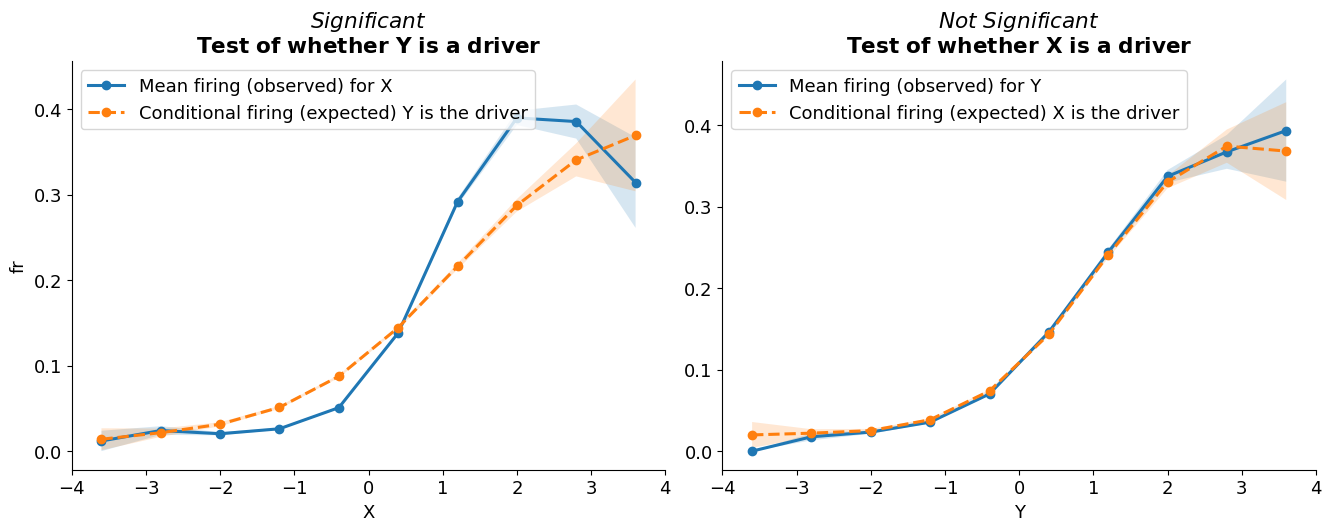

In [6]:
"""
Publication-ready demo: disentangling tuning to two correlated variables (linear case).
- Two curves on each subplot: Observed TF and Expected (conditional) TF
- Left: test whether Y is the driver of X  -> Significant
- Right: test whether X is the driver of Y -> Not Significant
- Same x-range on both panels, clear legends, CIs, and titles.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 120_000
Nbins = 10

# Correlated linear stimuli: X ~ N(0,1), Y = rho*X + sqrt(1-rho^2)*eps
rho = 0.85
X = rng.normal(0.0, 1.0, Nsamples)
eps = rng.normal(0.0, 1.0, Nsamples)
Y = rho * X + np.sqrt(1 - rho**2) * eps

# Poisson spiking truly tuned to X (nonlinear to ensure separation)
# Use a soft nonlinearity so TF_X is steep while TF_Y is smooth and lower.
def sigmoid(z): return 1 / (1 + np.exp(-z))
baseline = 0.02
amp = 0.4
theta = 0.8
rate = baseline + amp * sigmoid(2.2 * (X - theta))   # in "Hz" units for intuition
rate = np.clip(rate, 0, None)
spikes = rng.poisson(rate)

# ------------------------------- Helpers -------------------------------------
def make_edges(x, nbins, lo=-4.0, hi=4.0):
    """Fixed, symmetric binning so both panels share the same axis range."""
    return np.linspace(lo, hi, nbins + 1)

def digitize(x, edges):
    idx = np.digitize(x, edges, right=False) - 1
    return np.clip(idx, 0, len(edges) - 2)

def tuning(spikes, idx, nbins):
    """Mean, SEM, SD, N per bin (safe when N<=1)."""
    mean = np.zeros(nbins, float)
    sem  = np.zeros(nbins, float)
    sd   = np.zeros(nbins, float)
    n    = np.zeros(nbins, int)
    for b in range(nbins):
        m = (idx == b)
        n[b] = int(m.sum())
        if n[b] > 0:
            vals = spikes[m].astype(float)
            mean[b] = vals.mean()
            if n[b] > 1:
                sd[b]   = vals.std(ddof=1)
                sem[b]  = sd[b] / np.sqrt(n[b])
            else:
                sd[b] = 0.0
                sem[b] = np.nan
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
            sd[b]   = 0.0
    return mean, sem, sd, n

def counts_matrix(x, y, edges_x, edges_y):
    """Return counts C[y_bin, x_bin] (rows are y, cols are x)."""
    H, xedges, yedges = np.histogram2d(x, y, bins=[edges_x, edges_y], density=False)
    return H.T  # rows = y, cols = x

def conditional_from_counts(C):
    """P(y|x) and P(x|y) from counts matrix C[y, x]."""
    eps = 1e-12
    colsum = C.sum(axis=0, keepdims=True) + eps
    rowsum = C.sum(axis=1, keepdims=True) + eps
    P_y_given_x = C / colsum                     # shape (Nbins_y, Nbins_x)
    P_x_given_y = (C / rowsum).T                 # shape (Nbins_x, Nbins_y)
    return P_y_given_x, P_x_given_y

def expected_tf(tf_y, P_y_given_x):
    """E[tf_y | x] over bins. shapes: tf_y (Nbins_y,), P_y_given_x (Nbins_y, Nbins_x)."""
    return (tf_y[:, None] * P_y_given_x).sum(axis=0)

def expected_sem_from_second_moment(mean_y, sd_y, n_x, P_y_given_x):
    """
    Propagate second moment:
      s2_y = var_y + mean_y^2
      E[s2_y|x] - (E[mean_y|x])^2 = var_x    then  sem_x = sqrt(var_x / n_x)
    """
    s2_y = (sd_y**2) + (mean_y**2)
    E_mean = (mean_y[:, None] * P_y_given_x).sum(axis=0)
    E_s2   = (s2_y[:, None]   * P_y_given_x).sum(axis=0)
    var_x  = np.maximum(E_s2 - E_mean**2, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem_x = np.sqrt(var_x / np.maximum(n_x, 1))
    sem_x[n_x <= 1] = np.nan
    return sem_x

def ci_no_overlap(m1, s1, m2, s2, alpha=0.05):
    """Binwise Bonferroni-adjusted CI non-overlap."""
    valid = ~(np.isnan(m1) | np.isnan(s1) | np.isnan(m2) | np.isnan(s2))
    k = max(int(valid.sum()), 1)
    z = norm.ppf(1 - (alpha / k) / 2)
    lo1, hi1 = m1 - z * s1, m1 + z * s1
    lo2, hi2 = m2 - z * s2, m2 + z * s2
    out = (hi1 < lo2) | (lo1 > hi2)
    out[~valid] = False
    return out

# ------------------------- Bin, TFs, conditionals ----------------------------
edges = make_edges(X, Nbins)                 # same edges for X and Y plots
centres = 0.5 * (edges[:-1] + edges[1:])

idxX = digitize(X, edges)
idxY = digitize(Y, edges)

# Observed TFs
mean_X, sem_X, sd_X, n_X = tuning(spikes, idxX, Nbins)   # TF vs X
mean_Y, sem_Y, sd_Y, n_Y = tuning(spikes, idxY, Nbins)   # TF vs Y

# Conditionals from counts
C = counts_matrix(X, Y, edges, edges)       # C[y, x]
P_y_given_x, P_x_given_y = conditional_from_counts(C)

# Expected (null) curves using conditional expectations
# Left panel: NH says "Y drives X"  -> expected TF_X_from_Y
exp_X_from_Y = expected_tf(mean_Y, P_y_given_x)
sem_exp_X    = expected_sem_from_second_moment(mean_Y, sd_Y, n_X, P_y_given_x)

# Right panel: NH says "X drives Y" -> expected TF_Y_from_X
exp_Y_from_X = expected_tf(mean_X, P_x_given_y)  # note shape (Nbins_y,)
sem_exp_Y    = expected_sem_from_second_moment(mean_X, sd_X, n_Y, P_x_given_y)

# Significance masks (non-overlap of CIs)
sig_left  = ci_no_overlap(mean_X, sem_X, exp_X_from_Y, sem_exp_X)
sig_right = ci_no_overlap(mean_Y, sem_Y, exp_Y_from_X, sem_exp_Y)

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=False, constrained_layout=True)

# -------- Left: Test if Y is the driver (compare TF_X vs E[TF_Y|X]) ----------
axL.plot(centres, mean_X, "-o", lw=2.2, label="Mean firing (observed) for X")
axL.fill_between(centres, mean_X - sem_X, mean_X + sem_X, alpha=0.18)

axL.plot(centres, exp_X_from_Y, "--o", lw=2.2, label="Conditional firing (expected) Y is the driver")
axL.fill_between(centres, exp_X_from_Y - sem_exp_X, exp_X_from_Y + sem_exp_X, alpha=0.18)

axL.set_xlim(edges[0], edges[-1])
axL.set_xlabel("X")
axL.set_ylabel("fr")
title_left = r"$\it{Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ Y\ is\ a\ driver}$"
axL.set_title(title_left)
axL.legend(loc="upper left")

# -------- Right: Test if X is the driver (compare TF_Y vs E[TF_X|Y]) ---------
axR.plot(centres, mean_Y, "-o", lw=2.2, label="Mean firing (observed) for Y")
axR.fill_between(centres, mean_Y - sem_Y, mean_Y + sem_Y, alpha=0.18)

axR.plot(centres, exp_Y_from_X, "--o", lw=2.2, label="Conditional firing (expected) X is the driver")
axR.fill_between(centres, exp_Y_from_X - sem_exp_Y, exp_Y_from_X + sem_exp_Y, alpha=0.18)

axR.set_xlim(edges[0], edges[-1])
axR.set_xlabel("Y")
title_right = r"$\it{Not\ Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ X\ is\ a\ driver}$"
axR.set_title(title_right)
axR.legend(loc="upper left")

plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


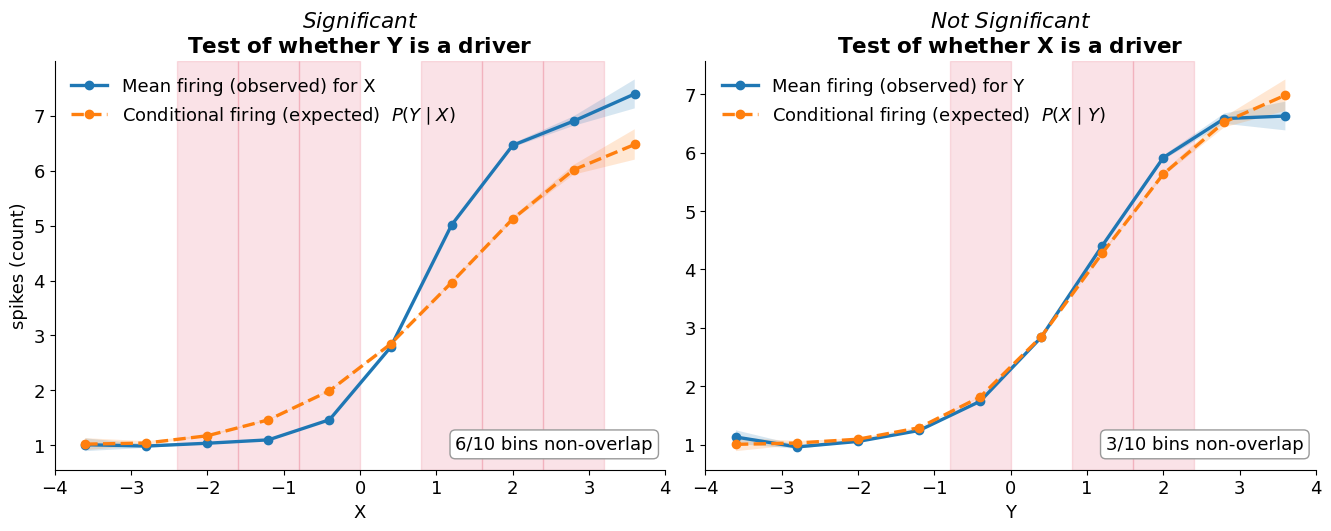

In [8]:
"""
Disentangling tuning to two correlated variables (linear, publication-ready).

Left: test whether Y drives X  -> compare TF_X vs E[TF_Y|X] using P(Y|X)  -> usually Significant
Right: test whether X drives Y -> compare TF_Y vs E[TF_X|Y] using P(X|Y)  -> usually Not Significant

Enhancements:
- Visual per-bin significance: translucent vertical bands where 95% CIs do NOT overlap (Bonferroni).
- Annotate conditionals (P(Y|X) / P(X|Y)) in each subplot.
- Higher Poisson rates and y-label "spikes (count)".
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import norm

# ------------------------------- Toy data ------------------------------------
rng = np.random.default_rng(0)
Nsamples = 120_000
Nbins = 10

# Correlated linear stimuli: X ~ N(0,1), Y = rho*X + sqrt(1-rho^2)*eps
rho = 0.85
X = rng.normal(0.0, 1.0, Nsamples)
eps = rng.normal(0.0, 1.0, Nsamples)
Y = rho * X + np.sqrt(1 - rho**2) * eps

# Poisson spiking truly tuned to X (steep nonlinearity -> separation)
def sigmoid(z): return 1 / (1 + np.exp(-z))
# Higher rates for clearer "spikes (count)" display
baseline = 1.0
amp = 6.0
theta = 0.8
rate = baseline + amp * sigmoid(2.2 * (X - theta))   # mean spikes per sample
rate = np.clip(rate, 0, None)
spikes = rng.poisson(rate)

# ------------------------------- Helpers -------------------------------------
def make_edges(nbins, lo=-4.0, hi=4.0):
    return np.linspace(lo, hi, nbins + 1)

def digitize(x, edges):
    idx = np.digitize(x, edges, right=False) - 1
    return np.clip(idx, 0, len(edges) - 2)

def tuning(spikes, idx, nbins):
    """Mean, SEM, SD, N per bin (robust for N<=1)."""
    mean = np.zeros(nbins, float)
    sem  = np.zeros(nbins, float)
    sd   = np.zeros(nbins, float)
    n    = np.zeros(nbins, int)
    for b in range(nbins):
        m = (idx == b)
        n[b] = int(m.sum())
        if n[b] > 0:
            vals = spikes[m].astype(float)
            mean[b] = vals.mean()
            if n[b] > 1:
                sd[b]  = vals.std(ddof=1)
                sem[b] = sd[b] / np.sqrt(n[b])
            else:
                sd[b] = 0.0
                sem[b] = np.nan
        else:
            mean[b] = np.nan
            sem[b]  = np.nan
            sd[b]   = 0.0
    return mean, sem, sd, n

def counts_matrix(x, y, edges_x, edges_y):
    """Counts C[y_bin, x_bin] (rows=y, cols=x)."""
    H, xedges, yedges = np.histogram2d(x, y, bins=[edges_x, edges_y], density=False)
    return H.T

def conditional_from_counts(C):
    """P(y|x) and P(x|y) from counts C[y, x]."""
    eps = 1e-12
    colsum = C.sum(axis=0, keepdims=True) + eps
    rowsum = C.sum(axis=1, keepdims=True) + eps
    P_y_given_x = C / colsum                  # (Nbins_y, Nbins_x)
    P_x_given_y = (C / rowsum).T              # (Nbins_x, Nbins_y)
    return P_y_given_x, P_x_given_y

def expected_tf(tf_y, P_y_given_x):
    """E[tf_y | x], tf_y: (Nbins_y,), P_y_given_x: (Nbins_y, Nbins_x)."""
    return (tf_y[:, None] * P_y_given_x).sum(axis=0)

def expected_sem_from_second_moment(mean_y, sd_y, n_x, P_y_given_x):
    """Propagate second moment for expected SEM under the null."""
    s2_y = (sd_y**2) + (mean_y**2)
    E_mean = (mean_y[:, None] * P_y_given_x).sum(axis=0)
    E_s2   = (s2_y[:, None]   * P_y_given_x).sum(axis=0)
    var_x  = np.maximum(E_s2 - E_mean**2, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem_x = np.sqrt(var_x / np.maximum(n_x, 1))
    sem_x[n_x <= 1] = np.nan
    return sem_x

def ci_no_overlap(m1, s1, m2, s2, alpha=0.05):
    """Binwise Bonferroni-adjusted CI non-overlap."""
    valid = ~(np.isnan(m1) | np.isnan(s1) | np.isnan(m2) | np.isnan(s2))
    k = max(int(valid.sum()), 1)
    z = norm.ppf(1 - (alpha / k) / 2)
    lo1, hi1 = m1 - z * s1, m1 + z * s1
    lo2, hi2 = m2 - z * s2, m2 + z * s2
    out = (hi1 < lo2) | (lo1 > hi2)
    out[~valid] = False
    return out

def draw_sig_bands(ax, edges, sig_mask, color="crimson", alpha=0.10, zorder=0):
    """Translucent vertical bands for bins where sig_mask is True."""
    for b, sig in enumerate(sig_mask):
        if sig:
            ax.axvspan(edges[b], edges[b+1], color=color, alpha=alpha, zorder=zorder)

# ------------------------- Bin, TFs, conditionals ----------------------------
edges = make_edges(Nbins, lo=-4.0, hi=4.0)
centres = 0.5 * (edges[:-1] + edges[1:])

idxX = digitize(X, edges)
idxY = digitize(Y, edges)

# Observed TFs
mean_X, sem_X, sd_X, n_X = tuning(spikes, idxX, Nbins)   # TF vs X
mean_Y, sem_Y, sd_Y, n_Y = tuning(spikes, idxY, Nbins)   # TF vs Y

# Conditionals from counts
C = counts_matrix(X, Y, edges, edges)       # C[y, x]
P_y_given_x, P_x_given_y = conditional_from_counts(C)

# Expected (null) curves and SEMs
# Left panel: NH "Y drives X" -> use P(Y|X)
exp_X_from_Y = expected_tf(mean_Y, P_y_given_x)
sem_exp_X    = expected_sem_from_second_moment(mean_Y, sd_Y, n_X, P_y_given_x)

# Right panel: NH "X drives Y" -> use P(X|Y)
exp_Y_from_X = expected_tf(mean_X, P_x_given_y)
sem_exp_Y    = expected_sem_from_second_moment(mean_X, sd_X, n_Y, P_x_given_y)

# Significance masks
sig_left  = ci_no_overlap(mean_X, sem_X, exp_X_from_Y, sem_exp_X)
sig_right = ci_no_overlap(mean_Y, sem_Y, exp_Y_from_X, sem_exp_Y)
k_left, k_right = int(sig_left.sum()), int(sig_right.sum())

# ------------------------------- Plotting ------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=False, constrained_layout=True)

# ----- Left: Test whether Y is a driver (compare TF_X vs E[TF_Y|X], uses P(Y|X)) -----
draw_sig_bands(axL, edges, sig_left, color="crimson", alpha=0.12, zorder=0)

axL.plot(centres, mean_X, "-o", lw=2.4, label="Mean firing (observed) for X")
axL.fill_between(centres, mean_X - sem_X, mean_X + sem_X, alpha=0.18)

axL.plot(centres, exp_X_from_Y, "--o", lw=2.4,
         label=r"Conditional firing (expected)  $P(Y\mid X)$")
axL.fill_between(centres, exp_X_from_Y - sem_exp_X, exp_X_from_Y + sem_exp_X, alpha=0.18)

axL.set_xlim(edges[0], edges[-1])
axL.set_xlabel("X")
axL.set_ylabel("spikes (count)")
axL.set_title(r"$\it{Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ Y\ is\ a\ driver}$")
axL.legend(loc="upper left", frameon=False)

# Badge with count of non-overlap bins
axL.text(0.98, 0.04, f"{k_left}/{Nbins} bins non-overlap",
         transform=axL.transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

# ----- Right: Test whether X is a driver (compare TF_Y vs E[TF_X|Y], uses P(X|Y)) -----
draw_sig_bands(axR, edges, sig_right, color="crimson", alpha=0.12, zorder=0)

axR.plot(centres, mean_Y, "-o", lw=2.4, label="Mean firing (observed) for Y")
axR.fill_between(centres, mean_Y - sem_Y, mean_Y + sem_Y, alpha=0.18)

axR.plot(centres, exp_Y_from_X, "--o", lw=2.4,
         label=r"Conditional firing (expected)  $P(X\mid Y)$")
axR.fill_between(centres, exp_Y_from_X - sem_exp_Y, exp_Y_from_X + sem_exp_Y, alpha=0.18)

axR.set_xlim(edges[0], edges[-1])
axR.set_xlabel("Y")
axR.set_title(r"$\it{Not\ Significant}$" + "\n" + r"$\bf{Test\ of\ whether\ X\ is\ a\ driver}$")
axR.legend(loc="upper left", frameon=False)

axR.text(0.98, 0.04, f"{k_right}/{Nbins} bins non-overlap",
         transform=axR.transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

# save to eps
save_path = r"Z:\Laurence\thesis\efizz_chapter"
fig.savefig(save_path + r"\disentangling_linear.eps", format="eps", dpi=300)

plt.show()
